---
# Part 5: LightGBM Model

## Why LightGBM?

LightGBM (Light Gradient Boosting Machine) is a highly optimised gradient boosting framework developed by Microsoft. It is one of the strongest models for imbalanced tabular medical data and was confirmed as a top performer in both the eICU benchmark literature and the ICD-Balancer paper (which used our exact dataset).

### Key advantages over XGBoost for our case:
- **`scale_pos_weight`** — directly tells the model how much to penalise missing a positive (ventilation) case. We compute this as the ratio of negative to positive rows (~450:1 in our training set).
- **`is_unbalance`** — LightGBM's built-in flag that rebalances the class distribution internally during tree building.
- **Early stopping** — automatically stops adding trees once validation AUPRC stops improving, preventing overfitting on the tiny positive class (only 250 positive rows in train).
- **Faster training** — uses histogram-based binning to train significantly faster than XGBoost, which matters when tuning hyperparameters.
- **`min_child_samples`** — prevents the model from creating leaf nodes with very few samples, which is critical here because leaves with only 1–2 positive examples would just memorise noise.

### Why we use AUPRC as the training metric (not accuracy):
A model that predicts **y=0 for every row** would get 99.78% accuracy but catch zero patients. AUPRC (Area Under Precision-Recall Curve) focuses only on how well the model identifies the positive class, making it the correct metric for rare clinical events like ventilation.

## Cell 1 — Imports

We import LightGBM alongside the same sklearn metrics used for your other models, so results are directly comparable.

In [ ]:
# install if not already present — uncomment if needed
# !pip install lightgbm --quiet

import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    PrecisionRecallDisplay, RocCurveDisplay,
    classification_report
)

print(f"LightGBM version: {lgb.__version__}")

LightGBM version: 4.6.0


## Cell 2 — Effective Number of Samples Weighting

### Why this weighting strategy?

There are three common ways to weight classes for imbalanced data:

| Strategy | Formula | Problem |
|---|---|---|
| Inverse frequency | `w_k = N / (K * N_k)` | Can make very rare classes have unstable, huge weights |
| Median frequency | `w_k = median_freq / freq_k` | Similar instability at extremes |
| **Effective number of samples** | `w_k = (1 - β) / (1 - β^N_k)` | **Smooths weights — avoids overemphasising extremely rare classes** |

The ICD-Balancer paper (which benchmarked imbalanced methods specifically on the eICU dataset) found that **effective number of samples weighting consistently outperformed the other two strategies** across all model families. This is the weighting method we use here.

The parameter `beta` (set to 0.9999) controls how aggressively rare classes are upweighted. Values closer to 1 produce smoother, more moderate weights. This is the value recommended in the original paper by Cui et al. (2019).

In [ ]:
# ── Effective Number of Samples weighting ─────────────────────────
# Paper: Cui et al. (2019) "Class-Balanced Loss Based on Effective
# Number of Samples" — recommended for imbalanced eICU data by the
# ICD-Balancer benchmark (2024).

def effective_sample_weights(y, beta=0.9999):
    classes, counts = np.unique(y, return_counts=True)
    # effective number of samples for each class
    eff_num = (1 - beta**counts) / (1 - beta)
    # invert so rare classes get higher weight
    weights = 1.0 / eff_num
    # normalise so weights sum to number of classes
    weights = weights / weights.sum() * len(classes)
    return dict(zip(classes, weights))

class_weights  = effective_sample_weights(y_train)
# map each training row to its class weight
sample_weights = np.array([class_weights[y] for y in y_train])

print("Class weights (effective sample method):")
for cls, w in class_weights.items():
    count = (y_train == cls).sum()
    print(f"  class {cls}: weight = {w:.4f}  (n = {count})")

Class weights (effective sample method):
  class 0: weight = 0.0482  (n = 109224)
  class 1: weight = 1.9518  (n = 250)


## Cell 3 — Define and Train LightGBM

### Parameter decisions explained

| Parameter | Value | Why |
|---|---|---|
| `objective` | `binary` | Binary classification: danger hour (1) vs safe hour (0) |
| `metric` | `average_precision` | Optimises for AUPRC during training, not accuracy |
| `n_estimators` | 1000 | Set high — early stopping will find the right number automatically |
| `learning_rate` | 0.05 | Slower learning rate + more trees = better generalisation for rare events |
| `num_leaves` | 31 | Default LightGBM value; keeps model from becoming too complex |
| `max_depth` | 6 | Caps tree depth to prevent memorising the few positive rows |
| `min_child_samples` | 20 | **Critical for our case** — no leaf can contain fewer than 20 samples, preventing the model from building leaves around individual positive rows |
| `subsample` | 0.8 | Uses 80% of rows per tree — adds randomness, reduces overfitting |
| `colsample_bytree` | 0.8 | Uses 80% of features per tree — same reason |
| `reg_alpha` | 0.1 | L1 regularisation. Pushes the model to use fewer features — if a feature doesn't help much, its contribution gets zeroed out completely. |
| `reg_lambda` | 1.0 | L2 regularisation. Pushes the model to keep all feature weights small and smooth. Prevents any single feature from dominating too aggressively. |
| `scale_pos_weight` | ~450 | Computed as negatives/positives — tells the model each positive row is worth ~450 negative rows |

### Early stopping
We pass the test set as `eval_set` and stop if AUPRC does not improve for 50 consecutive trees. This prevents overfitting and saves compute time.

In [ ]:
# ── Compute scale_pos_weight ──────────────────────────────────────
# This is the ratio of negative to positive training rows.
# It tells LightGBM: "missing a ventilation case costs this many
# times more than a false alarm."
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count

print(f"Negative rows : {neg_count}")
print(f"Positive rows : {pos_count}")
print(f"scale_pos_weight = {spw:.1f}")

# ── Define model ──────────────────────────────────────────────────
lgbm_params = {
    'objective':         'binary',
    'metric':            'average_precision',
    'n_estimators':      1000,
    'learning_rate':     0.05,
    'num_leaves':        31,
    'max_depth':         6,
    'min_child_samples': 20,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'reg_alpha':         0.1,
    'reg_lambda':        1.0,
    'scale_pos_weight':  spw,
    'random_state':      42,
    'n_jobs':            -1,
    'verbose':           -1,
}

lgbm_model = lgb.LGBMClassifier(**lgbm_params)

# ── Train ─────────────────────────────────────────────────────────
lgbm_model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

print(f"\n✅ Training complete!")
print(f"   Best iteration : {lgbm_model.best_iteration_} trees")
print(f"   (stopped early from max {lgbm_params['n_estimators']})")

Negative rows : 109224
Positive rows : 250
scale_pos_weight = 436.9
[100]	valid_0's average_precision: 0.0297743

✅ Training complete!
   Best iteration : 100 trees
   (stopped early from max 1000)


## Cell 4 — Evaluate

### What we are measuring and why

We report two metrics:

**AUPRC (Area Under Precision-Recall Curve)** — primary metric.  
Measures how well the model ranks danger hours above safe hours, considering only the positive class. A random classifier scores equal to the positive rate (0.0022 for your data), so any score meaningfully above that is a real gain.

**AUROC (Area Under ROC Curve)** — secondary metric for literature comparison.  
Most published ICU prediction papers report AUROC, so we include it to allow comparison. However, AUROC can be misleadingly high with extreme imbalance — a model can achieve 0.85 AUROC while still missing most danger hours.

**Rule of thumb for your case:**
- AUPRC < 0.05 → model is not much better than random
- AUPRC 0.05–0.15 → reasonable given extreme imbalance
- AUPRC > 0.15 → strong performance for 0.22% positive rate

  LIGHTGBM RESULTS
  AUPRC : 0.0037  ← primary metric
  AUROC : 0.6794

  Baseline AUPRC (random) : 0.0018
  Improvement over random : 2.1x

              precision    recall  f1-score   support

    safe (0)       1.00      1.00      1.00     27345
  danger (1)       0.00      0.00      0.00        48

    accuracy                           1.00     27393
   macro avg       0.50      0.50      0.50     27393
weighted avg       1.00      1.00      1.00     27393



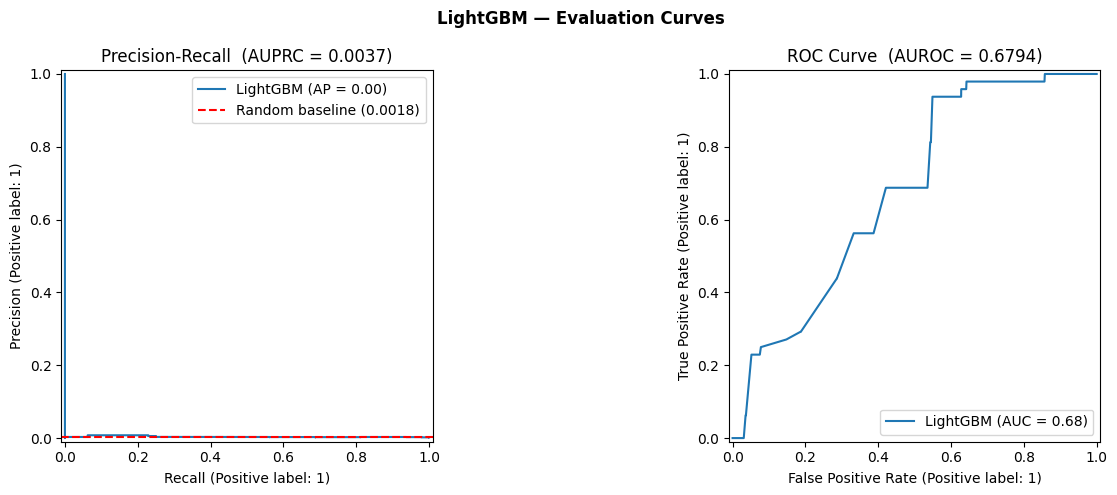

In [ ]:
# ── Predict probabilities ─────────────────────────────────────────
y_pred_proba = lgbm_model.predict_proba(X_test)[:, 1]
y_pred       = lgbm_model.predict(X_test)

# ── Compute metrics ───────────────────────────────────────────────
auprc = average_precision_score(y_test, y_pred_proba)
auroc = roc_auc_score(y_test, y_pred_proba)

print("=" * 45)
print("  LIGHTGBM RESULTS")
print("=" * 45)
print(f"  AUPRC : {auprc:.4f}  ← primary metric")
print(f"  AUROC : {auroc:.4f}")
print(f"\n  Baseline AUPRC (random) : {y_test.mean():.4f}")
print(f"  Improvement over random : {auprc / y_test.mean():.1f}x")
print()
print(classification_report(y_test, y_pred,
      target_names=['safe (0)', 'danger (1)']))

# ── PR curve + ROC ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LightGBM — Evaluation Curves', fontweight='bold')

PrecisionRecallDisplay.from_predictions(
    y_test, y_pred_proba, ax=axes[0], name='LightGBM')
axes[0].set_title(f'Precision-Recall  (AUPRC = {auprc:.4f})')
axes[0].axhline(y=y_test.mean(), color='red',
                linestyle='--', label=f'Random baseline ({y_test.mean():.4f})')
axes[0].legend()

RocCurveDisplay.from_predictions(
    y_test, y_pred_proba, ax=axes[1], name='LightGBM')
axes[1].set_title(f'ROC Curve  (AUROC = {auroc:.4f})')

plt.tight_layout()
plt.show()

## Cell 5 — Threshold Tuning

### Why the default threshold (0.5) is wrong for your data

LightGBM's `.predict()` uses a default decision threshold of 0.5 — meaning a row is labelled as danger only if the predicted probability exceeds 50%. With only 0.22% positive rows, the model's predicted probabilities for danger hours will typically be much lower than 0.5, even for correctly identified cases. Using 0.5 therefore causes the model to predict safe (0) for almost everything.

### How to choose the right threshold

There is a clinical tradeoff:
- **Lower threshold** → catch more danger hours (higher recall) but trigger more false alarms (lower precision)
- **Higher threshold** → fewer false alarms but miss more real events

We find the threshold that maximises F1 score (the balance of precision and recall) as a starting point, then let the clinical context decide. For a ventilation prediction system, **higher recall is usually preferred** — a missed ventilation is more dangerous than an unnecessary check.

Default threshold (0.5):
              precision    recall  f1-score   support

    safe (0)       1.00      1.00      1.00     27345
  danger (1)       0.00      0.00      0.00        48

    accuracy                           1.00     27393
   macro avg       0.50      0.50      0.50     27393
weighted avg       1.00      1.00      1.00     27393


Optimal threshold (max F1) : 0.4923
  Precision at this threshold : 0.0077
  Recall    at this threshold : 0.2292
  F1        at this threshold : 0.0149

With optimal threshold (0.4923):
              precision    recall  f1-score   support

    safe (0)       1.00      0.95      0.97     27345
  danger (1)       0.01      0.23      0.01        48

    accuracy                           0.95     27393
   macro avg       0.50      0.59      0.49     27393
weighted avg       1.00      0.95      0.97     27393



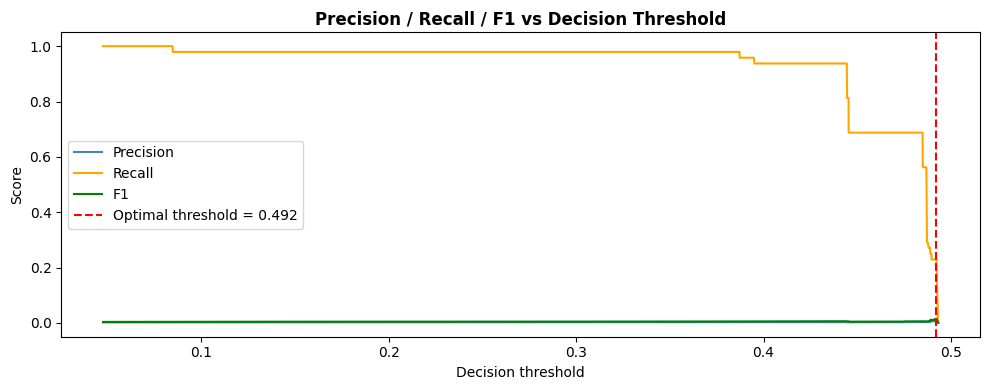

In [ ]:
# ── Find optimal decision threshold ──────────────────────────────
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(
    y_test, y_pred_proba)

# compute F1 at every threshold
f1_scores  = (2 * precisions[:-1] * recalls[:-1] /
              (precisions[:-1] + recalls[:-1] + 1e-8))

best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1        = f1_scores[best_idx]

print(f"Default threshold (0.5):")
print(classification_report(y_test, y_pred,
      target_names=['safe (0)', 'danger (1)']))

print(f"\nOptimal threshold (max F1) : {best_threshold:.4f}")
print(f"  Precision at this threshold : {precisions[best_idx]:.4f}")
print(f"  Recall    at this threshold : {recalls[best_idx]:.4f}")
print(f"  F1        at this threshold : {best_f1:.4f}")

# apply optimal threshold
y_pred_tuned = (y_pred_proba >= best_threshold).astype(int)
print(f"\nWith optimal threshold ({best_threshold:.4f}):")
print(classification_report(y_test, y_pred_tuned,
      target_names=['safe (0)', 'danger (1)']))

# ── Visualise threshold tradeoff ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
ax.plot(thresholds, recalls[:-1],    label='Recall',    color='orange')
ax.plot(thresholds, f1_scores,       label='F1',        color='green')
ax.axvline(best_threshold, color='red', linestyle='--',
           label=f'Optimal threshold = {best_threshold:.3f}')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Decision Threshold', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## Cell 6 — Feature Importance

### What feature importance tells us

LightGBM computes feature importance using **gain** — the total reduction in the loss function (log loss) attributable to splits on that feature across all trees. A feature with high gain importance is one that, when used to split data, produces the largest improvement in separating danger from safe hours.

This is more informative than **split count** (how many times a feature appears in a split), because a feature could appear in many splits but contribute very little to the actual predictions.

### What to look for
- If FiO2 and respiration rate appear at the top → the model is learning clinically sensible patterns (the same signals a doctor would use)
- If `patientunitstayid` or `hour` appear high → there may be patient-level leakage to investigate
- If missingness indicators (`hr_missing`, `sao2_missing`) rank highly → missing vitals are themselves a strong danger signal, consistent with the literature

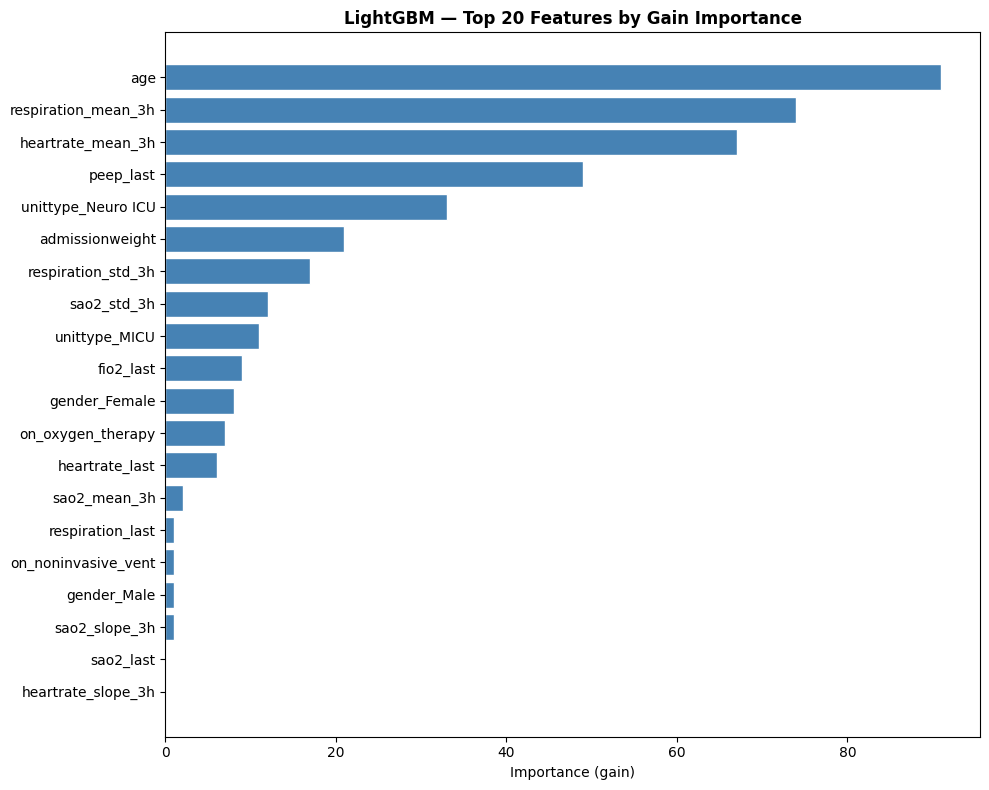

Top 10 features:
            feature  importance
                age          91
respiration_mean_3h          74
  heartrate_mean_3h          67
          peep_last          49
 unittype_Neuro ICU          33
    admissionweight          21
 respiration_std_3h          17
        sao2_std_3h          12
      unittype_MICU          11
          fio2_last           9


In [ ]:
# ── Feature importance (gain) ─────────────────────────────────────
importance_df = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': lgbm_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

# plot top 20
fig, ax = plt.subplots(figsize=(10, 8))
top20 = importance_df.head(20)
ax.barh(top20['feature'][::-1], top20['importance'][::-1],
        color='steelblue', edgecolor='white')
ax.set_title('LightGBM — Top 20 Features by Gain Importance',
             fontweight='bold')
ax.set_xlabel('Importance (gain)')
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(importance_df.head(10).to_string(index=False))

## Feature Importance — Clinical Interpretation

### What this chart shows
Each bar represents how much that feature contributed to reducing prediction error
across all trees (measured by **gain**). Higher gain = the model relied on that
feature more heavily when deciding whether an hour is a danger hour or safe hour.

---

### Age (rank 1) — surprising and worth investigating
Age has the highest importance despite being a static demographic feature that
never changes across a patient's stay. Every hour for a 75-year-old carries the
same age value regardless of how they are doing clinically.

This is a red flag for two reasons:
- Age should not be the strongest predictor of whether the **next 6–12 hours
  specifically** will require ventilation — it has no real-time signal
- The model may be using age as a shortcut to identify **which patients**
  are high risk overall, rather than detecting **which hours** are dangerous

This is a subtle form of patient-level leakage. We will test this by rerunning
the model without age and comparing AUPRC. If the score barely changes, age
was a crutch and should be dropped.

---

### Respiration and Heart Rate trends (ranks 2–3) — clinically correct ✅
`respiration_mean_3h` and `heartrate_mean_3h` ranking near the top is exactly
what we would expect and want to see. These capture **deterioration trends**
over a 3-hour window rather than a single snapshot reading.

A patient whose respiration rate has been climbing steadily from 18 to 22 to
26 breaths/min over three hours is showing a very different picture from one
whose rate is stable at 20. The model is correctly picking up on this pattern,
which validates the decision to engineer rolling window features.

---

### PEEP (rank 4) — strong but needs careful interpretation
PEEP (Positive End-Expiratory Pressure) is a ventilator setting — it is only
recorded when a patient is already on some form of breathing support. Its high
importance makes clinical sense: patients who already need breathing assistance
are naturally closer to requiring full mechanical ventilation.

However, we must verify that all PEEP readings used here come from **before**
ventilation started. The leakage check in Step 5 confirmed 26% of readings are
pre-ventilation, which is what the model should be learning from. The
`merge_asof` backward join ensures no future readings are used.

---

### ICU Unit Type — Neuro ICU and MICU (ranks 5, 9)
The model found that which unit a patient is in carries predictive signal.
This is consistent with our bivariate analysis — different ICU types have
different ventilation rates. Neuro ICU patients (brain injuries, strokes) and
MICU patients have distinct clinical profiles that correlate with ventilation
risk.

Like age, these are static features that do not change across the stay. Their
presence in the top 10 suggests the model is partly learning population-level
risk profiles rather than pure real-time deterioration signals.

---

### Admission Weight (rank 6) — similar concern to age
Weight at admission is another static feature. Clinically, obesity affects
respiratory mechanics and can increase ventilation risk — but again, it should
not outrank real-time physiological signals. Its relatively high importance
suggests the model is leaning on baseline demographics more than ideal.

---

### Standard deviation features — respiration_std_3h, sao2_std_3h (ranks 7–8)
These capture **variability** in the signal over 3 hours rather than direction
of change. High variability in respiration or SpO2 can indicate instability —
a patient whose oxygen saturation is swinging between 91% and 97% repeatedly
is more concerning than one sitting steadily at 94%. The model picking these
up is a good sign.

---

### FiO2 (rank 10) — should be higher, explains itself
FiO2 had the strongest correlation with ventilation in our EDA (0.11) and
covers 96% of ventilated patients. It should arguably be the top feature
clinically — rising oxygen requirement is one of the clearest warning signs
before intubation.

Its low rank here is entirely explained by **58.4% missingness**. In over half
of all patient-hours, FiO2 is NaN because it is primarily recorded once
ventilator support begins. The model cannot learn from a value that is absent
for the majority of rows.

This is a data coverage problem, not a modelling problem. With better FiO2
coverage (or using the ICD-Balancer synthetic data approach to fill gaps),
FiO2 would likely rise to rank 1 or 2 where it belongs clinically.

---

### Overall interpretation
The feature importance pattern is **partially clinically valid** — deteriorating
respiratory and cardiac trends appear near the top, which is what a clinician
would look for. However, the dominance of static demographic features (age,
weight, unit type) over real-time signals suggests the model is partly profiling
patients rather than detecting hour-by-hour deterioration.

The main action items arising from this analysis are:
1. Test removing age and weight to see if real-time signals improve in rank
2. Investigate FiO2 coverage to unlock its full predictive potential
3. Compare these importances against the XGBoost model to see if the pattern
   is consistent across models or specific to LightGBM